# Otomoto Market Segmentation

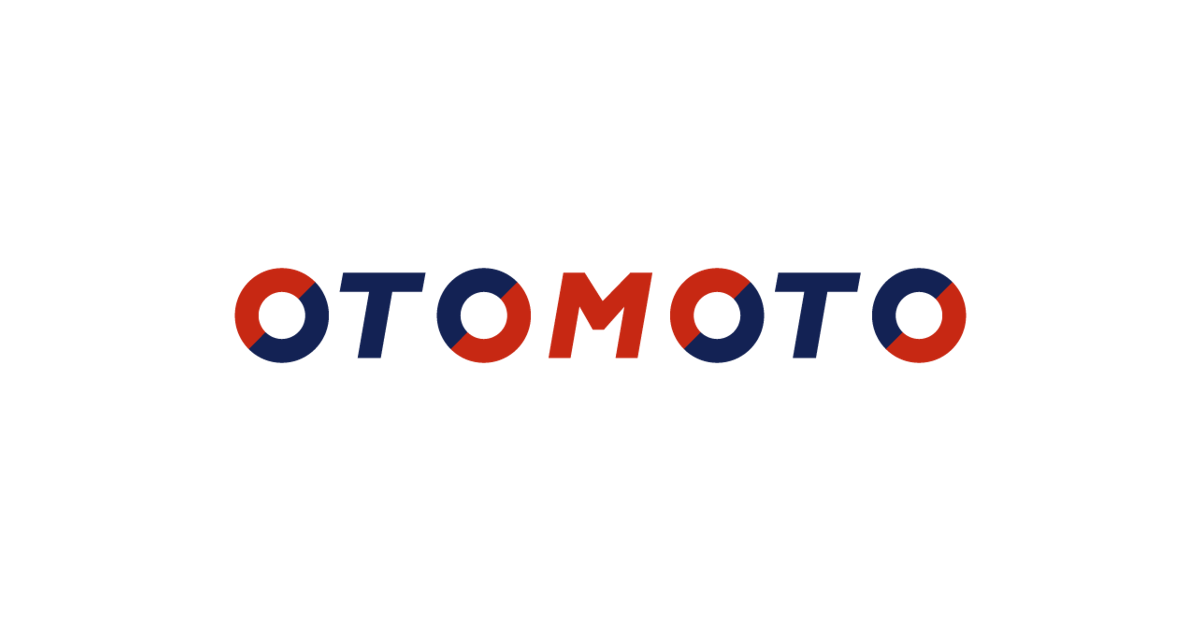

### Introduction
In the world of marketing, understanding your customer base is crucial. Otomoto has decided to leverage machine learning to improve its marketing segmentation. Otomoto has a wealth of customer data but has continously struggled to effectively segment its audience. They have decided to use machine learning models to optimize their segmentation. At the heart of these models lay optimization algorithms, the tools responsible for improving the model's performance. This task aims to optimize the existing artificial neural network model for effective marketing campaigns for Otomoto.
By understanding customer preferences, segmentation allows marketers to craft messages that resonate, boost satisfaction, and improve campaign effectiveness. It also helps identify high-value customers and design targeted efforts that maximize ROI with measurable results (Customer Segmentation Models: Enhancing Targeted Marketing Strategies, n.d.)

### Objective
The objective of this study is to optmiize the existing market segmentation models for Otomoto.

### Base Model
We will first examine the existing base model for Otomoto and then analyse how we can optimize it for targeted customer segmentation.

### Data Exploration

In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Read in the data from Otomoto and check the first five rows.
df = pd.read_csv("../data/teleconnect.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Next, we get the summary of the dataset to understand it better.

#### Dataset Summary

In [3]:
info = df.info() # Get dataset information
missing = df.isnull().sum() # Check for missing values

info, missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(None,
 customerID          0
 gender              0
 SeniorCitizen       0
 Partner             0
 Dependents          0
 tenure              0
 PhoneService        0
 MultipleLines       0
 InternetService     0
 OnlineSecurity      0
 OnlineBackup        0
 DeviceProtection    0
 TechSupport         0
 StreamingTV         0
 StreamingMovies     0
 Contract            0
 PaperlessBilling    0
 PaymentMethod       0
 MonthlyCharges      0
 TotalCharges        0
 Churn               0
 dtype: int64)

✅ Dataset Summary
* Shape: 7043 rows × 21 columns - The dataset has a total of 7043 records each representing customer information in 21 columns.

* There are No missing values

* Target column: Churn (Yes or No) This can be used to derive the customer segments

*  The ID column is the 'customerID'. This will be dropped as it is not required for analysis.

✅ Data types:

* Numeric: SeniorCitizen, tenure, MonthlyCharges

* Categorical: Many (For instance gender, InternetService, Contract, etc.)

* TotalCharges column is object data type - This will need to be converted to numeric.



### Data Preprocessing
The data preprocessing stage involves dropping the customerID column, converting the TotalCharges column to float, Encoding the categorical features (one-hot encoding), Encoding the target (Churn) as binary, Scaling the numeric features, and Splitting the dataset into train/test sets. We will define functions to achieve this.

In [4]:
# Define the function for data pre-processing
def preprocess_data(df):
    df = df.copy() # Create a copy of the data frame

    # Drop the ID column
    df.drop('customerID', axis=1, inplace=True)
    
    # Convert TotalCharges column to numeric, coerce errors to NaN then fill with 0
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

    # Encode the target variable (Churn column)
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

    # Split features and target
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include=['object']).columns
    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

    # One-hot encode categorical variables
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Scale numerical features
    scaler = StandardScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test, X.shape[1]

In [5]:
# Call the preprocessing function
X_train, X_test, y_train, y_test, input_dim = preprocess_data(df)
input_dim, X_train.shape, y_train.shape

/var/folders/x3/3chfptdn2wd3_c3_4mgf48km0000gn/T/ipykernel_14672/2029539468.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


(30, (5634, 30), (5634,))

### Build Baseline model

In [7]:
# define function to build the base model
def build_baseline_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [8]:
# Build the baseline model
baseline_model = build_baseline_model(input_dim)
baseline_model.summary() # Get model summary

/Users/dominic/Downloads/Nexford_University/Applied Machine Learning for Analytics/module_6/otomoto-marketing-segmentation/venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Add early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the baseline model
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7651 - loss: 0.4875 - val_accuracy: 0.7924 - val_loss: 0.4412
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7981 - loss: 0.4288 - val_accuracy: 0.7862 - val_loss: 0.4413
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7992 - loss: 0.4131 - val_accuracy: 0.7986 - val_loss: 0.4342
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8230 - loss: 0.3966 - val_accuracy: 0.7906 - val_loss: 0.4353
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8073 - loss: 0.4093 - val_accuracy: 0.7933 - val_loss: 0.4352
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8176 - loss: 0.3973 - val_accuracy: 0.7968 - val_loss: 0.4336
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8006 - loss: 0.4177 - val_accuracy: 0.7950 - val_loss: 0.4417
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.4027 - val_accuracy: 0.

### Model Evaluation

In [12]:
# define a function to plot the training history
def plot_training_history(history):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

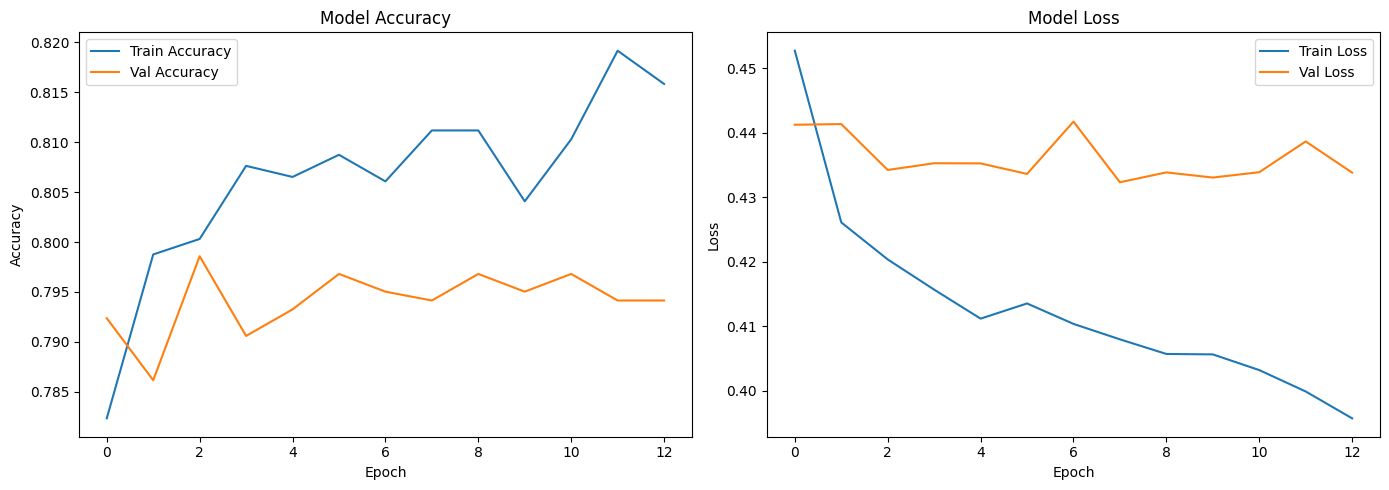

In [14]:
#Call the function on the model
plot_training_history(history)

In [13]:
# Evaluate the model
def evaluate_model(model, X_test, y_test):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return loss, accuracy

In [15]:
loss, accuracy = baseline_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7957 - loss: 0.4242
Test Loss: 0.4161
Test Accuracy: 0.7999


The plots suggest that the model is likely overfitting on the training data. The training accuracy keeps increasing, and the training loss keeps decreasing, but the validation accuracy plateaus and the validation loss starts to increase or fluctuate after a few epochs. To mitigate against overfitting and improve the model's generalization ability we will optimize the model.

### Model Optimization

Model optimization is the process of making improvements to a model with two main end goals:
* Enhance operational efficiency
* Enhance model effectiveness.
Model optimization is important because efficient model are more accurate and produce reliable results hence more value. Optimized model also cost less to run. There are various strategies used to improve a model:

* Retraining a model on higher-quality or more representative data - Retraining a machine learning model is only beneficial when the original training data was poor or no longer reflects current real-world conditions. If the initial data was good and the current data hasn't significantly changed, retraining is unlikely to improve the model's performance.
* Model Pruning - Involves removing some of the parameters in a model.
* Model Regularization - An underfitted model cannot interpret the data effectively, while an overfitted model interprets it inconsistently and makes inaccurate real-world decisions despite accurate training. Regularization is a technique that adjusts the importance (weight) a model gives to different data types, thereby improving its ability to interpret data accurately and address both underfitting and overfitting.